In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from wordcloud import WordCloud
from collections import Counter
import string
import pickle

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from xgboost import XGBClassifier

In [9]:
df = pd.read_csv('gibberish_data.csv', encoding='latin1')

In [11]:
# Pipeline:
# 1. Data cleaning
# 2. EDA
# 3. Text Preprocessing
# 4. Model building
# 5. Evaluation
# 6. Improvement

## 1. Data Cleaning

In [12]:
if 'response' in df.columns:
    df = df[['label', 'response']]
elif 'Response' in df.columns:
    df = df[['Label', 'Response']]
    
df.columns = ['target', 'text']

encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])
df = df.drop_duplicates(keep='first')
df.shape

(940536, 2)

## 2. EDA

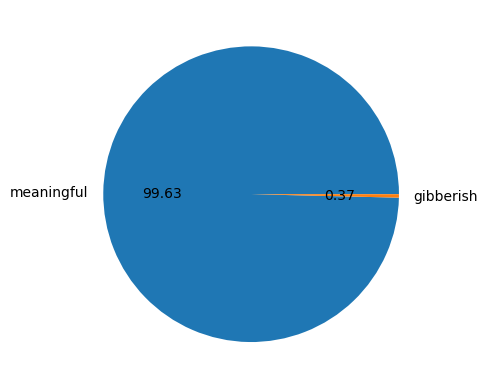

In [13]:
plt.pie(df['target'].value_counts(), labels=['meaningful','gibberish'], autopct="%0.2f")
plt.show()

In [14]:
nltk.download('punkt')
df['num_characters'] = df['text'].astype(str).apply(len)
df['num_words'] = df['text'].astype(str).str.split().str.len()
df['num_sentences'] = df['text'].astype(str).apply(lambda x: len(nltk.sent_tokenize(x)))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\avanc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [15]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,940536.000000,940536.000000,940536.000000
mean,421.050048,76.560433,4.889758
std,213.997935,38.711442,2.589027
min,1.000000,1.000000,1.000000
25%,233.000000,43.000000,3.000000
50%,388.000000,71.000000,4.000000
75%,603.000000,109.000000,6.000000
max,896.000000,223.000000,76.000000


## 3. Data Preprocessing

In [16]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
punct = set(string.punctuation)

def transform_text(text):
    text = str(text).lower()
    text = nltk.word_tokenize(text)
    
    y = [ps.stem(i) for i in text if i.isalnum() and i not in stop_words and i not in punct]
            
    return " ".join(y)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\avanc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [17]:
df['transformed_text'] = df['text'].apply(transform_text)

## 4. Model Building

In [18]:
tfidf = TfidfVectorizer(max_features=10000, analyzer='char', ngram_range=(2,3))
X = tfidf.fit_transform(df['transformed_text'])
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [19]:
mnb, bnb = MultinomialNB(), BernoulliNB()

for clf in [mnb, bnb]:
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(f"{type(clf).__name__} Accuracy: {accuracy_score(y_test, y_pred)}")
    print(f"{type(clf).__name__} Precision: {precision_score(y_test, y_pred)}")

MultinomialNB Accuracy: 0.9991387926085015
MultinomialNB Precision: 0.9992320204794539
BernoulliNB Accuracy: 0.9983998554022158
BernoulliNB Precision: 0.9999946546931794


In [20]:
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
rfc = RandomForestClassifier(n_estimators=50, random_state=2)

clfs = {'NB':mnb, 'ETC':etc, 'RF':rfc}

def train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    return accuracy_score(y_test, y_pred), precision_score(y_test, y_pred)

performance_df = pd.DataFrame(columns=['Algorithm', 'Accuracy', 'Precision'])

for name, clf in clfs.items():
    acc, prec = train_classifier(clf, X_train, y_train, X_test, y_test)
    performance_df = pd.concat([performance_df, pd.DataFrame({'Algorithm':[name], 'Accuracy':[acc], 'Precision':[prec]})], ignore_index=True)

performance_df.sort_values('Precision', ascending=False)

C:\Users\avanc\AppData\Local\Temp\ipykernel_13140\1813574551.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  performance_df = pd.concat([performance_df, pd.DataFrame({'Algorithm':[name], 'Accuracy':[acc], 'Precision':[prec]})], ignore_index=True)


,Algorithm,Accuracy,Precision
2,RF,0.999888,0.999936
1,ETC,0.999872,0.999931
0,NB,0.999139,0.999232


In [21]:
# Voting Classifier with the best-performing models
voting = VotingClassifier(estimators=[('rf', rfc), ('nb', mnb), ('et', etc)], voting='soft')
voting.fit(X_train, y_train)

# Final saving: RFC (Random Forest) had the best performance (99.99% precision)
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(rfc, open('model.pkl', 'wb'))